# 2.2 Clustering

In [1]:
# Libraries from snr_intro.ipynb
# data manipulation 
import pandas as pd
import numpy as np

# plotting
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib as mpl
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# neuron visualizations
from brainrender import Scene
from brainrender.actors import Points
from pathlib import Path

import vedo
vedo.settings.default_backend= 'vtk'

# For clustering
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster import hierarchy
from sklearn.metrics import silhouette_samples, silhouette_score
from scipy.cluster import hierarchy
from scipy.cluster import hierarchy
from sklearn.metrics import silhouette_samples, silhouette_score
from scipy.cluster.hierarchy import dendrogram


# For PCA
from sklearn.decomposition import PCA

# Extra libraries for pipelines, transformers etc
from sklearn.preprocessing import StandardScaler # scaling features
from sklearn.preprocessing import Normalizer
from sklearn.pipeline import make_pipeline           # combining classifier steps
from sklearn.pipeline import Pipeline 
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import OneHotEncoder

# For the mixture models
from sklearn.mixture import GaussianMixture

#  For metrics
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import adjusted_mutual_info_score
from sklearn.metrics import calinski_harabasz_score
from sklearn.metrics import pair_confusion_matrix 
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import silhouette_score
from itertools import combinations

# For cluster labelling analysis
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder

# Loading in data and preparing features for transformations

In [2]:
ec_snr_data = pd.read_csv("Data/master_detailed_comment.csv")

# Filter for the rows that are NA in proj column and apply the labels that we have assigned in classifying_SNR.ipynb
mask = ec_snr_data["proj"].isna()


In [3]:
# access the length and count columns
length_cols = [col for col in ec_snr_data if col.endswith("_length")]
count_cols = [col for col in ec_snr_data if col.endswith("_endpoint")]

# create a column transformer that scales them appropriately - take log(1+x) and then use standard scaler:
preprocessor_length = ColumnTransformer([
    (
        "log_and_scale",
        make_pipeline(
            FunctionTransformer(np.log1p),
            StandardScaler()
        ),
        length_cols
    )
])


# 2.2 Baseline - K-Means

In [4]:
from sklearn.metrics import silhouette_score, adjusted_rand_score
from itertools import combinations

# Plotting the clustering solution with different numbers of clusters
results_lengths = []
ari_lengths = []

n_runs = 20

for c in range(2, 21):

    labels_list = []
    wcv_list = []
    silhouette_list = []

    for seed in range(n_runs):

        km_pipe_l = Pipeline([
            ("prep", preprocessor_length),
            ("km", KMeans(
                n_clusters=c,
                n_init=10,
                init="k-means++",
                random_state=seed
            ))
        ])

        labels = km_pipe_l.fit_predict(ec_snr_data)

        X_transformed = km_pipe_l.named_steps["prep"].transform(ec_snr_data)

        labels_list.append(labels)
        wcv_list.append(km_pipe_l.named_steps["km"].inertia_)
        silhouette_list.append(silhouette_score(X_transformed, labels))

    # Pairwise ARI between all repeated runs for this value of c
    pairwise_ari = []

    for labels_a, labels_b in combinations(labels_list, 2):
        pairwise_ari.append(adjusted_rand_score(labels_a, labels_b))

    results_lengths.append({
        "clusters": c,
        "mean_WCV": np.mean(wcv_list),
        "sd_WCV": np.std(wcv_list),
        "mean_silhouette": np.mean(silhouette_list),
        "sd_silhouette": np.std(silhouette_list),
        "mean_ARI": np.mean(pairwise_ari),
        "sd_ARI": np.std(pairwise_ari),
        "min_ARI": np.min(pairwise_ari),
        "max_ARI": np.max(pairwise_ari)
    })

    for ari in pairwise_ari:
        ari_lengths.append({
            "clusters": c,
            "ARI": ari
        })

results_lengths = pd.DataFrame(results_lengths)
ari_lengths = pd.DataFrame(ari_lengths)

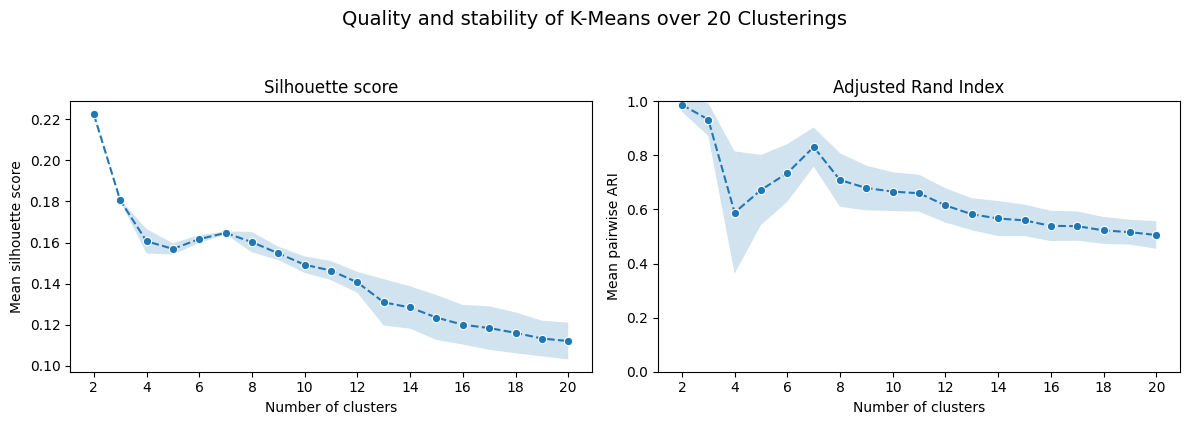

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

fig.suptitle(
    "Quality and stability of K-Means over 20 Clusterings",
    fontsize=14,
    y=1.05
)

# Shared x ticks: 2, 4, 6, ...
max_k = results_lengths["clusters"].max()
x_ticks = np.arange(2, max_k + 1, 2)

# Silhouette score
sns.lineplot(
    data=results_lengths,
    x="clusters",
    y="mean_silhouette",
    linestyle="dashed",
    marker="o",
    ax=axes[0]
)

axes[0].fill_between(
    results_lengths["clusters"],
    results_lengths["mean_silhouette"] - results_lengths["sd_silhouette"],
    results_lengths["mean_silhouette"] + results_lengths["sd_silhouette"],
    alpha=0.2
)

axes[0].set_xlabel("Number of clusters")
axes[0].set_ylabel("Mean silhouette score")
axes[0].set_title("Silhouette score")
axes[0].set_xticks(x_ticks)

# ARI
sns.lineplot(
    data=results_lengths,
    x="clusters",
    y="mean_ARI",
    linestyle="dashed",
    marker="o",
    ax=axes[1]
)

axes[1].fill_between(
    results_lengths["clusters"],
    results_lengths["mean_ARI"] - results_lengths["sd_ARI"],
    results_lengths["mean_ARI"] + results_lengths["sd_ARI"],
    alpha=0.2
)

axes[1].set_xlabel("Number of clusters")
axes[1].set_ylabel("Mean pairwise ARI")
axes[1].set_title("Adjusted Rand Index")
axes[1].set_ylim(0, 1)
axes[1].set_xticks(x_ticks)

plt.tight_layout()
fig.savefig(
    "Figures/Figure_4.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


# 2.2.3 GMMs

First create a function that will fit the model and plot the metrics I am interested in

In [6]:
def gmm_clustering_metric_plots(
    data,
    cols=length_cols,
    max_clusters=30,
    covariance_type="spherical",
    n_runs=20,
    n_init=10,
    init_params="k-means++"
):
    """
    Fit Gaussian mixture models across a range of cluster numbers and assess
    model quality and stability.

    For each value of K, the GMM is fitted several times using different random
    seeds. The function records model-selection metrics such as BIC and AIC,
    cluster-separation metrics such as silhouette score, and stability metrics
    based on pairwise agreement between repeated runs.

    Parameters
    ----------
    data : pd.DataFrame
        Input dataframe containing the projection length columns.
    cols : list
        Columns used as clustering features.
    max_clusters : int
        Upper limit for the number of GMM components. Models are fitted for
        K = 2, ..., max_clusters - 1.
    covariance_type : str
        Covariance structure used by the GMM.
    n_runs : int
        Number of repeated fits for each value of K.
    n_init : int
        Number of initialisations used internally by each GMM fit.
    init_params : str
        Initialisation method for the GMM.

    Returns
    -------
    summary : pd.DataFrame
        Mean and standard deviation of metrics for each value of K.
    run_results : pd.DataFrame
        Metrics from every individual GMM run.
    stability_results : pd.DataFrame
        Pairwise ARI and AMI comparisons between runs.
    """

    # Store model-quality metrics from each individual run.
    run_results = []

    # Store pairwise comparisons between repeated runs for the same K.
    stability_results = []

    # Try different numbers of mixture components.
    for k in range(2, max_clusters):

        # Save the cluster labels from each run so that stability can be assessed.
        labels_by_run = []

        for seed in range(n_runs):

            # Each GMM is fitted after applying the same preprocessing:
            # log-transform the projection lengths, then standardise them.
            gmm_pipe = make_pipeline(
                ColumnTransformer(
                    [(
                        "log_scale",
                        make_pipeline(
                            FunctionTransformer(np.log1p),
                            StandardScaler()
                        ),
                        cols
                    )]
                ),
                GaussianMixture(
                    n_components=k,
                    covariance_type=covariance_type,
                    init_params=init_params,
                    n_init=n_init,
                    random_state=seed
                )
            )

            # Fit the preprocessing and GMM model.
            gmm_pipe.fit(data)

            # Extract the transformed feature matrix and fitted GMM.
            # The sklearn pipeline does not pass the transformed data directly
            # to the metric functions, so it is recovered here.
            X_trans = gmm_pipe[:-1].transform(data)
            gmm = gmm_pipe[-1]

            # Hard labels are used for separation metrics.
            labels = gmm.predict(X_trans)

            # Soft labels are used to assess how confident the GMM assignments are.
            probs = gmm.predict_proba(X_trans)

            labels_by_run.append(labels)

            # Save metrics for this particular value of K and random seed.
            run_results.append({
                "n_components": k,
                "run": seed,
                "BIC": gmm.bic(X_trans),
                "AIC": gmm.aic(X_trans),
                "log_likelihood": gmm.score(X_trans),
                "silhouette": silhouette_score(X_trans, labels),
                "calinski_harabasz": calinski_harabasz_score(X_trans, labels),
                "davies_bouldin": davies_bouldin_score(X_trans, labels),
                "mean_max_prob": probs.max(axis=1).mean(),
                "min_max_prob": probs.max(axis=1).min()
            })

        # Compare every pair of runs for this K.
        # High ARI/AMI means repeated fits give similar cluster assignments.
        for a in range(n_runs):
            for b in range(a + 1, n_runs):

                stability_results.append({
                    "n_components": k,
                    "run_a": a,
                    "run_b": b,
                    "ARI": adjusted_rand_score(labels_by_run[a], labels_by_run[b]),
                    "AMI": adjusted_mutual_info_score(labels_by_run[a], labels_by_run[b])
                })

    # Convert stored results into dataframes for summarising and plotting.
    run_results = pd.DataFrame(run_results)
    stability_results = pd.DataFrame(stability_results)

    # Summarise model-quality and cluster-separation metrics across repeated runs.
    summary = (
        run_results
        .groupby("n_components")
        .agg(
            BIC_mean=("BIC", "mean"),
            BIC_sd=("BIC", "std"),
            AIC_mean=("AIC", "mean"),
            AIC_sd=("AIC", "std"),
            silhouette_mean=("silhouette", "mean"),
            silhouette_sd=("silhouette", "std"),
            calinski_harabasz_mean=("calinski_harabasz", "mean"),
            davies_bouldin_mean=("davies_bouldin", "mean"),
            mean_max_prob_mean=("mean_max_prob", "mean"),
            min_max_prob_mean=("min_max_prob", "mean")
        )
        .reset_index()
    )

    # Summarise clustering stability across repeated runs.
    stability_summary = (
        stability_results
        .groupby("n_components")
        .agg(
            ARI_mean=("ARI", "mean"),
            ARI_sd=("ARI", "std"),
            AMI_mean=("AMI", "mean"),
            AMI_sd=("AMI", "std")
        )
        .reset_index()
    )

    # Combine quality and stability summaries into one table.
    summary = summary.merge(stability_summary, on="n_components")

    # Plot the main diagnostics used for choosing K.
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    fig.suptitle(
        f"Clustering metrics for {covariance_type} covariance GMM",
        fontsize=15,
        y=1.05
    )

    def plot_mean_with_sd(ax, y_mean, y_sd, title, ylabel, color=None):
        """
        Plot the mean value of a metric with a +/- 1 standard deviation band.
        """
        x = summary["n_components"].to_numpy()
        y = summary[y_mean].to_numpy()
        sd = summary[y_sd].to_numpy()

        sns.lineplot(
            data=summary,
            x="n_components",
            y=y_mean,
            marker="o",
            ax=ax,
            color=color
        )

        # Match the uncertainty band to the line colour.
        line_colour = ax.lines[-1].get_color()

        ax.fill_between(
            x,
            y - sd,
            y + sd,
            alpha=0.2,
            color=line_colour
        )

        ax.set_title(title)
        ax.set_xlabel("Number of components")
        ax.set_ylabel(ylabel)

        max_k = summary["n_components"].max()
        ax.set_xticks(np.arange(2, max_k + 1, 2))

    # BIC rewards model fit but penalises extra parameters.
    # Lower values indicate a better trade-off between fit and complexity.
    plot_mean_with_sd(
        ax=axes[0],
        y_mean="BIC_mean",
        y_sd="BIC_sd",
        title="BIC",
        ylabel="Mean BIC\n(lower is better)",
        color="red"
    )

    # Silhouette score measures how separated the resulting hard labels are.
    # Higher values indicate better-separated clusters.
    plot_mean_with_sd(
        ax=axes[1],
        y_mean="silhouette_mean",
        y_sd="silhouette_sd",
        title="Silhouette score",
        ylabel="Mean silhouette score"
    )

    axes[1].set_ylim(
        min(-0.05, summary["silhouette_mean"].min() - summary["silhouette_sd"].max()),
        min(1, summary["silhouette_mean"].max() + summary["silhouette_sd"].max() + 0.05)
    )

    # ARI measures whether repeated runs produce similar cluster assignments.
    # Higher values indicate a more stable clustering solution.
    plot_mean_with_sd(
        ax=axes[2],
        y_mean="ARI_mean",
        y_sd="ARI_sd",
        title="Stability across runs",
        ylabel="Mean pairwise ARI"
    )

    axes[2].set_ylim(0, 1)

    plt.tight_layout()
    plt.show()

    return summary, run_results, stability_results

Now get the results for each of the covariance types 

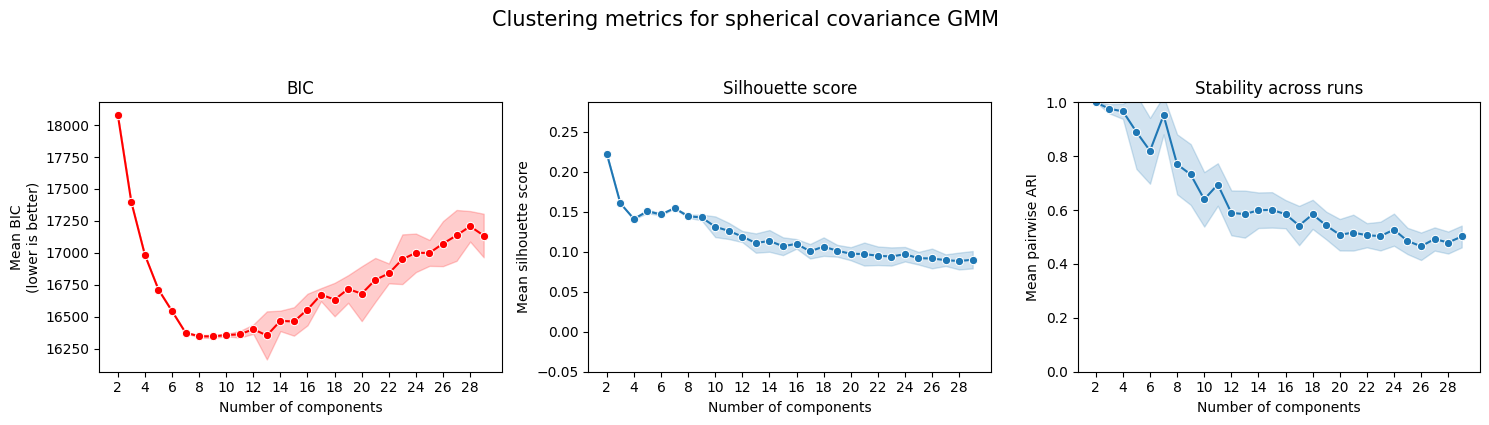

In [7]:
# Spherical
summary1, run_results1, stability_results1 = gmm_clustering_metric_plots(
    ec_snr_data,
    cols=length_cols,
    max_clusters=30,
    covariance_type="spherical",
    n_runs=10,
    n_init=10,
    init_params="k-means++"
)

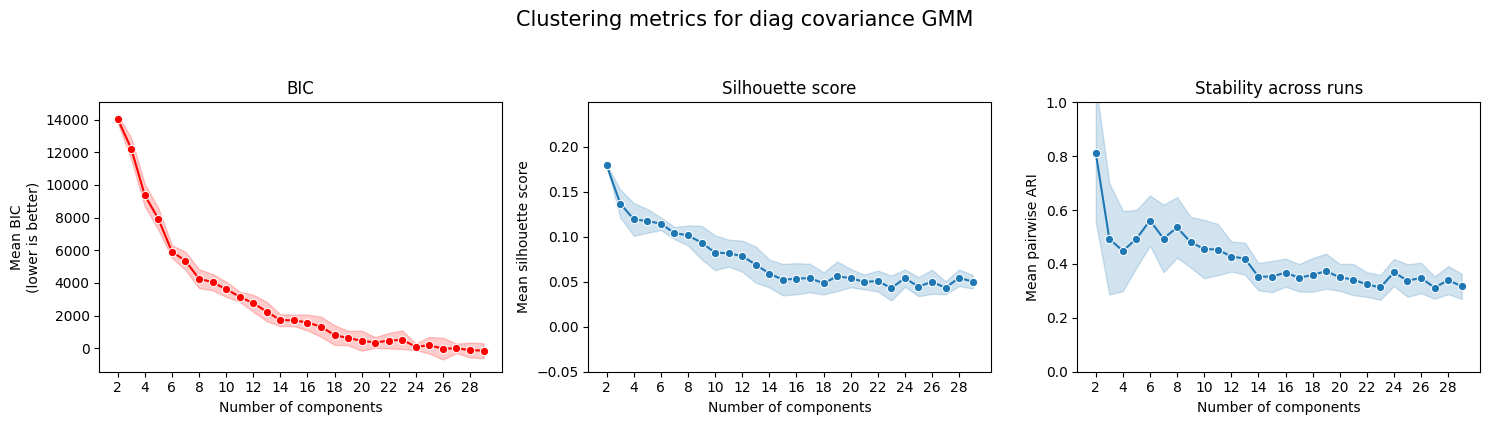

In [8]:
# Diagonal
summary2, run_results2, stability_results2 = gmm_clustering_metric_plots(
    ec_snr_data,
    cols=length_cols,
    max_clusters=30,
    covariance_type="diag",
    n_runs=10,
    n_init=10,
    init_params="k-means++"
)

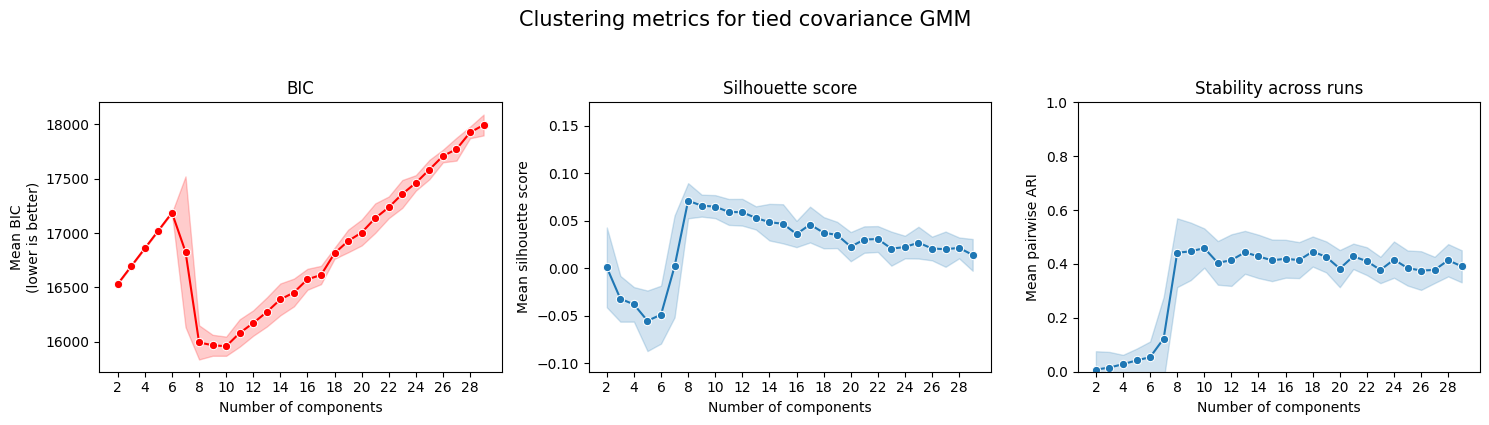

In [9]:
# Tied 
summary3, run_results3, stability_results3 = gmm_clustering_metric_plots(
    ec_snr_data,
    cols=length_cols,
    max_clusters=30,
    covariance_type="tied",
    n_runs=10,
    n_init=10,
    init_params="k-means++"
)

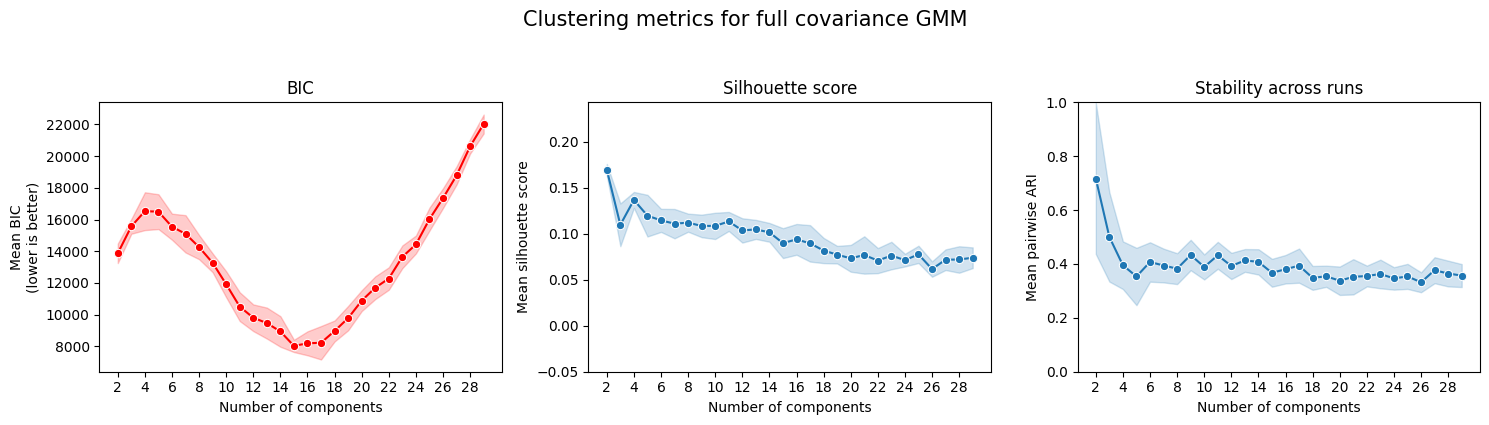

In [10]:
# Full
summary4, run_results4, stability_results4 = gmm_clustering_metric_plots(
    ec_snr_data,
    cols=length_cols,
    max_clusters=30,
    covariance_type="full",
    n_runs=10,
    n_init=10,
    init_params="k-means++"
)

## Figure 5

Now create a plot for all four covariance types across BIC, silhouette score and ARI

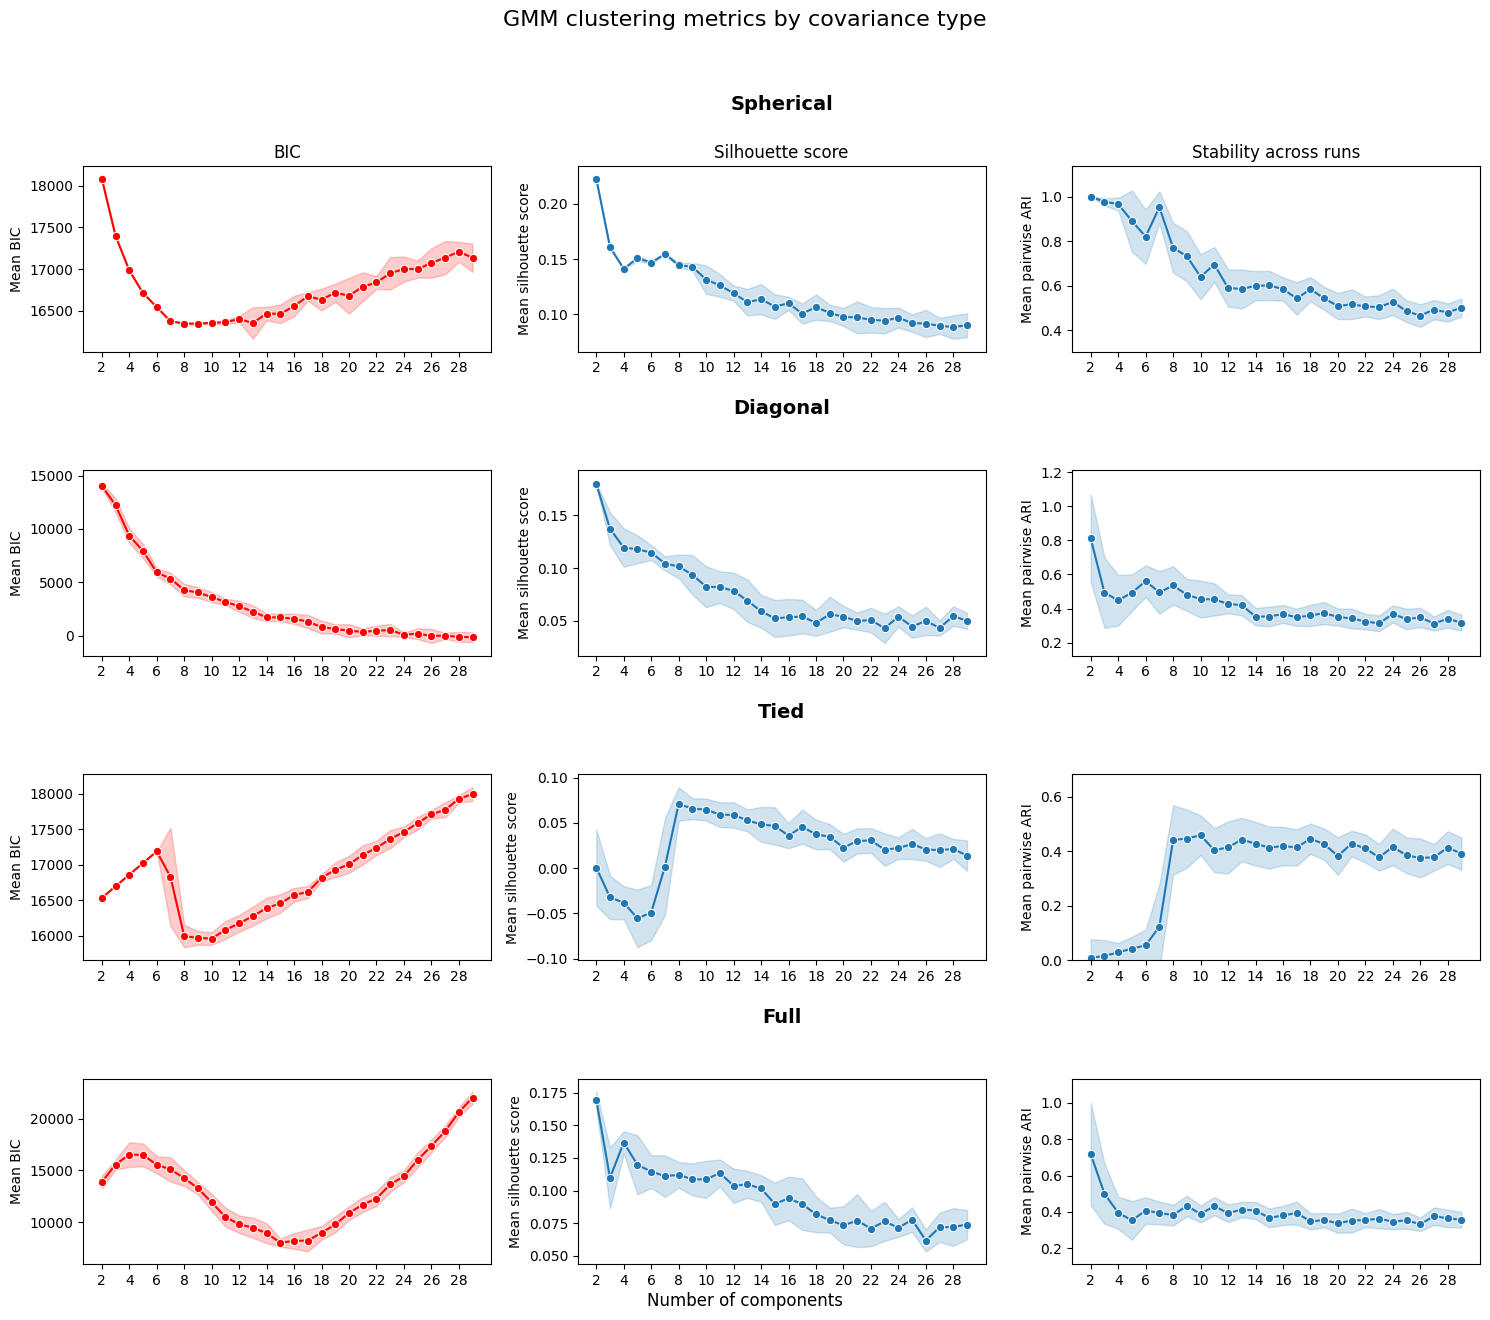

In [11]:
summaries = {
    "Spherical": summary1,
    "Diagonal": summary2,
    "Tied": summary3,
    "Full": summary4
}

metrics = [
    {
        "mean": "BIC_mean",
        "sd": "BIC_sd",
        "title": "BIC",
        "ylabel": "Mean BIC",
        "color": "red"
    },
    {
        "mean": "silhouette_mean",
        "sd": "silhouette_sd",
        "title": "Silhouette score",
        "ylabel": "Mean silhouette score",
        "color": None
    },
    {
        "mean": "ARI_mean",
        "sd": "ARI_sd",
        "title": "Stability across runs",
        "ylabel": "Mean pairwise ARI",
        "color": None
    }
]

# Shared x-axis ticks
all_k = np.concatenate([
    df["n_components"].to_numpy()
    for df in summaries.values()
])

x_min = all_k.min()
x_max = all_k.max()
x_ticks = np.arange(x_min, x_max + 1, 2)

fig, axes = plt.subplots(
    nrows=4,
    ncols=3,
    figsize=(15, 13),
    sharex=True,
    sharey=False
)

fig.suptitle(
    "GMM clustering metrics by covariance type",
    fontsize=16,
    y=1.02
)

def get_ylim(y, sd, metric_name):
    """
    Get y-limits that include the full mean +/- sd region,
    with extra space for ARI.
    """
    lower = np.nanmin(y - sd)
    upper = np.nanmax(y + sd)

    if metric_name == "ARI_mean":
        padding_fraction = 0.18
    else:
        padding_fraction = 0.08

    padding = padding_fraction * (upper - lower)

    y_min = lower - padding
    y_max = upper + padding

    # Keep lower bounds sensible
    if metric_name == "ARI_mean":
        y_min = max(0, y_min)
        # Do not cap y_max at 1, otherwise the plot can look cramped
    elif metric_name == "silhouette_mean":
        y_min = max(-1, y_min)
        y_max = min(1, y_max)

    return y_min, y_max

for row_idx, (cov_name, df) in enumerate(summaries.items()):

    # Row title above the middle plot
    axes[row_idx, 1].text(
        0.5,
        1.28,
        cov_name,
        transform=axes[row_idx, 1].transAxes,
        ha="center",
        va="bottom",
        fontsize=14,
        fontweight="bold"
    )

    for col_idx, metric in enumerate(metrics):

        ax = axes[row_idx, col_idx]

        x = df["n_components"].to_numpy()
        y = df[metric["mean"]].to_numpy()
        sd = df[metric["sd"]].to_numpy()

        sns.lineplot(
            x=x,
            y=y,
            marker="o",
            ax=ax,
            color=metric["color"]
        )

        line_colour = ax.lines[-1].get_color()

        ax.fill_between(
            x,
            y - sd,
            y + sd,
            alpha=0.2,
            color=line_colour
        )

        ax.set_ylim(get_ylim(y, sd, metric["mean"]))
        ax.set_xticks(x_ticks)

        # Column titles only on the top row
        if row_idx == 0:
            ax.set_title(metric["title"], fontsize=12)

        ax.set_ylabel(metric["ylabel"])

        # x-axis label only on bottom row
        ax.set_xlabel("")
        ax.tick_params(axis="x", labelbottom=True)

fig.supxlabel("Number of components", y=0.02, fontsize=12)
plt.tight_layout()
fig.savefig(
    "Figures/Figure_5.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# 2.2.4 Hieararchical Agglomerative Clustering

## Functions required for plotting dendrogram and associated visualisations

In [12]:
# Feature creation:

def add_projection_features(
    data,
    cols,
    target_threshold=0.1,
    single_threshold=0.70
):
    """
    Add projection-derived features to neuron dataframe.

    Parameters
    ----------
    data : pd.DataFrame
        Original neuron dataframe.
    length_cols : list
        Columns containing axon length values.
    target_threshold : float
        Fraction threshold for counting a region as a target.
    single_threshold : float
        Fraction threshold for calling a neuron single-target.

    Returns
    -------
    data_out : pd.DataFrame
        Copy of data with extra projection features.
    fractions : pd.DataFrame
        Row-normalised projection fractions.
    """

    data_out = data.copy()

    # Total axon length
    data_out["total_length"] = data_out[cols].sum(axis=1)

    # Fractions
    fractions = data_out[cols].div(
        data_out["total_length"].replace(0, np.nan),
        axis=0
    )

    fractions.columns = [
        col.replace("_length", "")
        for col in cols
    ]

    # Size class
    qs = data_out["total_length"].quantile([0.05, 0.10, 0.25, 0.75, 0.90, 0.95])

    def size_class(x):
        if x <= qs.loc[0.05]:
            return "xxs"
        elif x <= qs.loc[0.10]:
            return "xs"
        elif x <= qs.loc[0.25]:
            return "s"
        elif x <= qs.loc[0.75]:
            return "m"
        elif x <= qs.loc[0.90]:
            return "l"
        elif x <= qs.loc[0.95]:
            return "xl"
        else:
            return "xxl"

    data_out["size_class"] = data_out["total_length"].apply(size_class)

    # Number of targets
    data_out["n_targets"] = (fractions > target_threshold).sum(axis=1)

    # Dominant target and fraction
    data_out["dominant_target"] = fractions.idxmax(axis=1)
    data_out["dominant_fraction"] = fractions.max(axis=1)

    # Top 3 targets
    data_out["top3_targets"] = fractions.apply(
        lambda row: "_".join(row.nlargest(3).index),
        axis=1
    )

    # Single target label
    def get_single_target(row):
        if row.max() > single_threshold:
            return f"single_{row.idxmax()}"
        return np.nan

    data_out["single_target"] = fractions.apply(get_single_target, axis=1)

    # Projection entropy
    def projection_entropy(row):
        p = row[row > 0]
        return -(p * np.log(p)).sum()

    data_out["projection_entropy"] = fractions.apply(projection_entropy, axis=1)

    # Top fractions
    data_out["top1_fraction"] = fractions.apply(lambda x: x.nlargest(1).iloc[-1], axis=1)
    data_out["top2_fraction"] = fractions.apply(lambda x: x.nlargest(2).iloc[-1], axis=1)
    data_out["top3_fraction"] = fractions.apply(lambda x: x.nlargest(3).iloc[-1], axis=1)

    # Human-readable label
    data_out["projection_label"] = (
        data_out["size_class"]
        + "_n"
        + data_out["n_targets"].astype(str)
        + "_"
        + data_out["top3_targets"]
    )

    mask = data_out["single_target"].notna()

    data_out.loc[mask, "projection_label"] = (
        data_out.loc[mask, "size_class"]
        + "_"
        + data_out.loc[mask, "single_target"]
        + "_n"
        + data_out.loc[mask, "n_targets"].astype(str)
        + "_"
        + data_out.loc[mask, "top3_targets"]
    )

    return data_out, fractions

In [13]:
def add_right_colorbar(
    fig,
    ax,
    im,
    label,
    ticks=None,
    ticklabels=None,
    width="1.2%",
    x_offset=1.01
):
    """
    Add a slim colourbar just to the right of an annotation axis.
    """
    cax = inset_axes(
        ax,
        width=width,
        height="100%",
        loc="lower left",
        bbox_to_anchor=(x_offset, 0, 1, 1),
        bbox_transform=ax.transAxes,
        borderpad=0
    )

    cbar = fig.colorbar(im, cax=cax)

    if ticks is not None:
        cbar.set_ticks(ticks)

    if ticklabels is not None:
        cbar.set_ticklabels(ticklabels)

    cbar.ax.tick_params(labelsize=7, length=2)
    cbar.set_label(label, fontsize=7, rotation=270, labelpad=12)

    return cbar

In [14]:
def plot_projection_dendrogram(
    X,
    data,
    fractions,
    target_levels,
    method="average",
    metric="euclidean",
    color_threshold=None,
    figsize=(18, 15),
    frac_vmax=0.25,
    total_length_log=False,
    title=None,
    cluster_labels=None,
    cluster_label_name="GMM"
):
    """
    Plot dendrogram with projection annotation strips.

    Parameters
    ----------
    X : array-like
        Matrix used for hierarchical clustering.

    data : pd.DataFrame
        DataFrame containing projection features and original length columns.

    fractions : pd.DataFrame
        Row-normalised projection fractions.

    target_levels : list
        Desired order of projection target rows.

    method : str, default="average"
        Linkage method, e.g. "average", "complete", "ward".

    metric : str, default="euclidean"
        Distance metric, e.g. "euclidean", "cosine".

    color_threshold : float or None, default=None
        Dendrogram colour threshold.

    figsize : tuple, default=(18, 15)
        Figure size.

    frac_vmax : float, default=0.25
        Upper colour limit for projection fraction heatmap.

    total_length_log : bool, default=False
        If True, plot log1p(total_length) rather than raw total_length.

    title : str or None, default=None
        Optional figure title.

    cluster_labels : array-like or None, default=None
        Optional external cluster labels, e.g. GMM labels.
        Must be in the same row order as data.

    cluster_label_name : str, default="GMM"
        Label shown beside the optional cluster strip.

    Returns
    -------
    fig : matplotlib.figure.Figure
        Figure object.

    axes : dict
        Dictionary of axes.

    hc : ndarray
        Linkage matrix.

    leaf_order : list
        Row order of neurons in the dendrogram.
    """

    # Linkage
    hc = hierarchy.linkage(
        X,
        method=method,
        metric=metric
    )

    has_cluster_labels = cluster_labels is not None

    # Create axes
    if has_cluster_labels:
        fig, (
            ax_dendro,
            ax_cluster,
            ax_balance,
            ax_ntargets,
            ax_total,
            ax_size,
            ax_top1,
            ax_frac
        ) = plt.subplots(
            8,
            1,
            figsize=figsize,
            gridspec_kw={
                "height_ratios": [5, 0.25, 0.25, 0.25, 0.25, 3, 5, 5]
            },
            sharex=True
        )
    else:
        fig, (
            ax_dendro,
            ax_balance,
            ax_ntargets,
            ax_total,
            ax_size,
            ax_top1,
            ax_frac
        ) = plt.subplots(
            7,
            1,
            figsize=figsize,
            gridspec_kw={
                "height_ratios": [5, 0.25, 0.25, 0.25, 3, 5, 5]
            },
            sharex=True
        )

    # Dendrogram
    dendro = dendrogram(
        hc,
        ax=ax_dendro,
        no_labels=True,
        color_threshold=color_threshold,
        above_threshold_color="black"
    )

    leaf_order = dendro["leaves"]
    xmin, xmax = ax_dendro.get_xlim()

    if title is None:
        title = f"Hierarchical clustering: method={method}, metric={metric}"

    ax_dendro.set_title(title)

    # Reorder data to match dendrogram leaves
    data_ordered = data.iloc[leaf_order].copy()
    fractions_ordered = fractions.iloc[leaf_order].copy()

    # Optional external cluster label strip
    if has_cluster_labels:
        cluster_labels = np.asarray(cluster_labels)

        if len(cluster_labels) != len(data):
            raise ValueError(
                "cluster_labels must have the same length as data, "
                "and must be in the same row order."
            )

        cluster_ordered = cluster_labels[leaf_order]

        cluster_categories = pd.Categorical(cluster_ordered)
        cluster_codes = cluster_categories.codes
        cluster_names = cluster_categories.categories

        cmap_cluster = ListedColormap(
            plt.cm.tab20(np.linspace(0, 1, len(cluster_names)))
        )

        ax_cluster.imshow(
            cluster_codes.reshape(1, -1),
            aspect="auto",
            cmap=cmap_cluster,
            vmin=-0.5,
            vmax=len(cluster_names) - 0.5,
            extent=[xmin, xmax, 0, 1]
        )

        ax_cluster.set_yticks([0.5])
        ax_cluster.set_yticklabels([cluster_label_name])
        ax_cluster.set_xticks([])

    # ORB/RSP balance
    orb = data_ordered["ORB_length"]
    rsp = data_ordered["RSP_length"]

    balance = np.where(
        orb + rsp > 0,
        (orb - rsp) / (orb + rsp),
        np.nan
    )

    cmap_balance = plt.cm.bwr.copy()
    cmap_balance.set_bad("lightgrey")

    ax_balance.imshow(
        balance.reshape(1, -1),
        aspect="auto",
        cmap=cmap_balance,
        vmin=-1,
        vmax=1,
        extent=[xmin, xmax, 0, 1]
    )

    ax_balance.set_yticks([0.5])
    ax_balance.set_yticklabels(["ORB ↔ RSP"])
    ax_balance.set_xticks([])

    # Number of targets
    n_targets = data_ordered["n_targets"].to_numpy()

    ax_ntargets.imshow(
        n_targets.reshape(1, -1),
        aspect="auto",
        cmap="viridis",
        vmin=np.nanmin(n_targets),
        vmax=np.nanmax(n_targets),
        extent=[xmin, xmax, 0, 1]
    )

    ax_ntargets.set_yticks([0.5])
    ax_ntargets.set_yticklabels(["n targets"])
    ax_ntargets.set_xticks([])

    # Total length
    total_length = data_ordered["total_length"].to_numpy()

    if total_length_log:
        total_length = np.log1p(total_length)
        total_label = "log total\nlength"
    else:
        total_label = "total\nlength"

    ax_total.imshow(
        total_length.reshape(1, -1),
        aspect="auto",
        cmap="plasma",
        vmin=np.nanmin(total_length),
        vmax=np.nanmax(total_length),
        extent=[xmin, xmax, 0, 1]
    )

    ax_total.set_yticks([0.5])
    ax_total.set_yticklabels([total_label])
    ax_total.set_xticks([])

    # Size class one-hot matrix
    size_ordered = data_ordered["size_class"]

    size_matrix = pd.get_dummies(size_ordered).T

    size_levels = ["xxs", "xs", "s", "m", "l", "xl", "xxl"]

    size_matrix = size_matrix.reindex(
        size_levels,
        fill_value=0
    )

    size_img = size_matrix.to_numpy(dtype=float)

    ax_size.imshow(
        size_img,
        aspect="auto",
        cmap="Greys",
        vmin=0,
        vmax=1,
        origin="upper",
        extent=[xmin, xmax, size_img.shape[0], 0]
    )

    ax_size.set_yticks(np.arange(size_img.shape[0]) + 0.5)
    ax_size.set_yticklabels(size_matrix.index, fontsize=7)
    ax_size.set_xticks([])
    ax_size.set_ylabel("Size\nclass")

    # Reorder fractions to desired projection-target order
    fractions_ordered = fractions_ordered.reindex(
        columns=target_levels
    )

    # Dominant target one-hot matrix
    dominant_ordered = data_ordered["dominant_target"]

    top1_matrix = pd.get_dummies(dominant_ordered).T

    top1_matrix = top1_matrix.reindex(
        target_levels,
        fill_value=0
    )

    top1_img = top1_matrix.to_numpy(dtype=float)
    n_top1_rows = top1_img.shape[0]

    ax_top1.imshow(
        top1_img,
        aspect="auto",
        cmap="Greys",
        vmin=0,
        vmax=1,
        origin="upper",
        extent=[xmin, xmax, n_top1_rows, 0]
    )

    ax_top1.set_yticks(np.arange(n_top1_rows) + 0.5)
    ax_top1.set_yticklabels(top1_matrix.index, fontsize=7)
    ax_top1.set_xticks([])
    ax_top1.set_ylabel("Dominant\ntarget")

    # Projection fraction heatmap
    frac_img = fractions_ordered.T.to_numpy()
    n_frac_rows = frac_img.shape[0]

    ax_frac.imshow(
        frac_img,
        aspect="auto",
        cmap="mako",
        vmin=0,
        vmax=frac_vmax,
        origin="upper",
        extent=[xmin, xmax, n_frac_rows, 0]
    )

    ax_frac.set_yticks(np.arange(n_frac_rows) + 0.5)
    ax_frac.set_yticklabels(fractions_ordered.columns, fontsize=6)
    ax_frac.set_xticks([])
    ax_frac.set_ylabel("Projection\ntarget")
    ax_frac.set_xlabel("Neurons in dendrogram order")

    # Align annotation panels with dendrogram
    axes_to_align = [
        ax_balance,
        ax_ntargets,
        ax_total,
        ax_size,
        ax_top1,
        ax_frac
    ]

    if has_cluster_labels:
        axes_to_align = [ax_cluster] + axes_to_align

    for ax in axes_to_align:
        ax.set_xlim(xmin, xmax)

    fig.subplots_adjust(hspace=0.02)

    plt.show()

    axes = {
        "dendrogram": ax_dendro,
        "balance": ax_balance,
        "n_targets": ax_ntargets,
        "total_length": ax_total,
        "size_class": ax_size,
        "dominant_target": ax_top1,
        "fractions": ax_frac
    }

    if has_cluster_labels:
        axes["cluster_labels"] = ax_cluster

    return fig, axes, hc, leaf_order

In [15]:
def plot_dendrogram_legend_figure(
    cluster_names=None,
    cluster_colors=None,
    n_targets_range=(1, 10),
    total_length_range=(0, 1),
    frac_vmax=0.25,
    total_length_log=False,
    cluster_label_name="GMM",
    figsize=(14, 6)
):
    """
    Make a separate figure containing:
    - cluster label legend
    - colour scales for continuous strips
    - explanation for one-hot matrices
    """

    fig = plt.figure(figsize=figsize, constrained_layout=True)
    gs = fig.add_gridspec(
        2, 4,
        height_ratios=[1.3, 1.0]
    )

    # Axes
    ax_cluster = fig.add_subplot(gs[0, :2])
    ax_binary = fig.add_subplot(gs[0, 2:])
    ax_balance = fig.add_subplot(gs[1, 0])
    ax_ntargets = fig.add_subplot(gs[1, 1])
    ax_total = fig.add_subplot(gs[1, 2])
    ax_frac = fig.add_subplot(gs[1, 3])

    fig.suptitle("Annotation legend for dendrogram", fontsize=16)

    # --------------------------
    # Cluster label legend
    # --------------------------
    ax_cluster.axis("off")

    if cluster_names is not None and cluster_colors is not None:
        handles = [
            mpatches.Patch(
                facecolor=cluster_colors[i],
                edgecolor="none",
                label=str(name)
            )
            for i, name in enumerate(cluster_names)
        ]

        ax_cluster.legend(
            handles=handles,
            title=cluster_label_name,
            loc="center left",
            frameon=False,
            ncol=min(3, len(handles)),
            fontsize=16,
            title_fontsize=14
        )
    else:
        ax_cluster.text(
            0.0, 0.5,
            "No cluster-label strip included",
            va="center",
            ha="left",
            fontsize=14
        )

    # --------------------------
    # One-hot / binary explanation
    # --------------------------
    ax_binary.axis("off")

    binary_handles = [
        mpatches.Patch(
            facecolor="black",
            edgecolor="black",
            label="black = assigned / present"
        ),
        mpatches.Patch(
            facecolor="white",
            edgecolor="black",
            label="white = not assigned / absent"
        ),
        mpatches.Patch(
            facecolor="lightgrey",
            edgecolor="black",
            label="grey in ORB↔RSP strip = no ORB or RSP length"
        )
    ]

    ax_binary.legend(
        handles=binary_handles,
        title="Matrix / strip key",
        loc="center left",
        frameon=False,
        fontsize=14,
        title_fontsize=14
    )

    # --------------------------
    # ORB/RSP balance colourbar
    # --------------------------
    cmap_balance = plt.cm.bwr.copy()
    sm_balance = ScalarMappable(
        norm=Normalize(vmin=-1, vmax=1),
        cmap=cmap_balance
    )
    sm_balance.set_array([])

    cbar_balance = fig.colorbar(
        sm_balance,
        cax=ax_balance,
        orientation="horizontal"
    )
    cbar_balance.set_ticks([-1, 0, 1])
    cbar_balance.set_ticklabels(["RSP", "equal", "ORB"])
    ax_balance.set_title("ORB/RSP balance", fontsize=14)

    # --------------------------
    # Number of targets colourbar
    # --------------------------
    nt_min, nt_max = n_targets_range
    sm_nt = ScalarMappable(
        norm=Normalize(vmin=nt_min, vmax=nt_max),
        cmap="viridis"
    )
    sm_nt.set_array([])

    cbar_nt = fig.colorbar(
        sm_nt,
        cax=ax_ntargets,
        orientation="horizontal"
    )

    if nt_max - nt_min <= 6:
        nt_ticks = np.arange(nt_min, nt_max + 1)
    else:
        nt_ticks = np.linspace(nt_min, nt_max, 5)

    cbar_nt.set_ticks(nt_ticks)
    ax_ntargets.set_title("Number of targets", fontsize=14)

    # --------------------------
    # Total length colourbar
    # --------------------------
    tl_min, tl_max = total_length_range
    sm_total = ScalarMappable(
        norm=Normalize(vmin=tl_min, vmax=tl_max),
        cmap="plasma"
    )
    sm_total.set_array([])

    cbar_total = fig.colorbar(
        sm_total,
        cax=ax_total,
        orientation="horizontal"
    )
    ax_total.set_title(
        "log1p(total length)" if total_length_log else "Total length",
        fontsize=14
    )

    # --------------------------
    # Projection fraction colourbar
    # --------------------------
    sm_frac = ScalarMappable(
        norm=Normalize(vmin=0, vmax=frac_vmax),
        cmap="mako"
    )
    sm_frac.set_array([])

    cbar_frac = fig.colorbar(
        sm_frac,
        cax=ax_frac,
        orientation="horizontal"
    )
    cbar_frac.set_ticks([0, frac_vmax / 2, frac_vmax])
    cbar_frac.set_ticklabels([
        "0",
        f"{frac_vmax / 2:.2f}",
        f"{frac_vmax:.2f}"
    ])
    ax_frac.set_title("Projection fraction", fontsize=14)


    plt.show()

    return fig

In [16]:
target_levels = ["ACA","AI",
    "AMY","AUD","CLA","ECT","EP","FRP","GU","HIP","ILA","MO","OLF","ORB","PAR","PERI","PL","POST","PRE","PTLp","RSP","SS","STRd","STRv","SUB",
    "TEa","VISC","VIS","VISpor"
]

In [17]:
gmm_pipe_7 = make_pipeline(
                ColumnTransformer(
                    [("log",
                      make_pipeline(
                          FunctionTransformer(np.log1p),
                          StandardScaler()
                      ),
                      length_cols)]
                ),
                GaussianMixture(
                    n_components=7,
                    covariance_type='spherical',
                    init_params='k-means++',
                    n_init=10,
                    random_state = 24601
                )
            )

gmm_7_labs = gmm_pipe_7.fit_predict(ec_snr_data)

## Figure 6 & 7

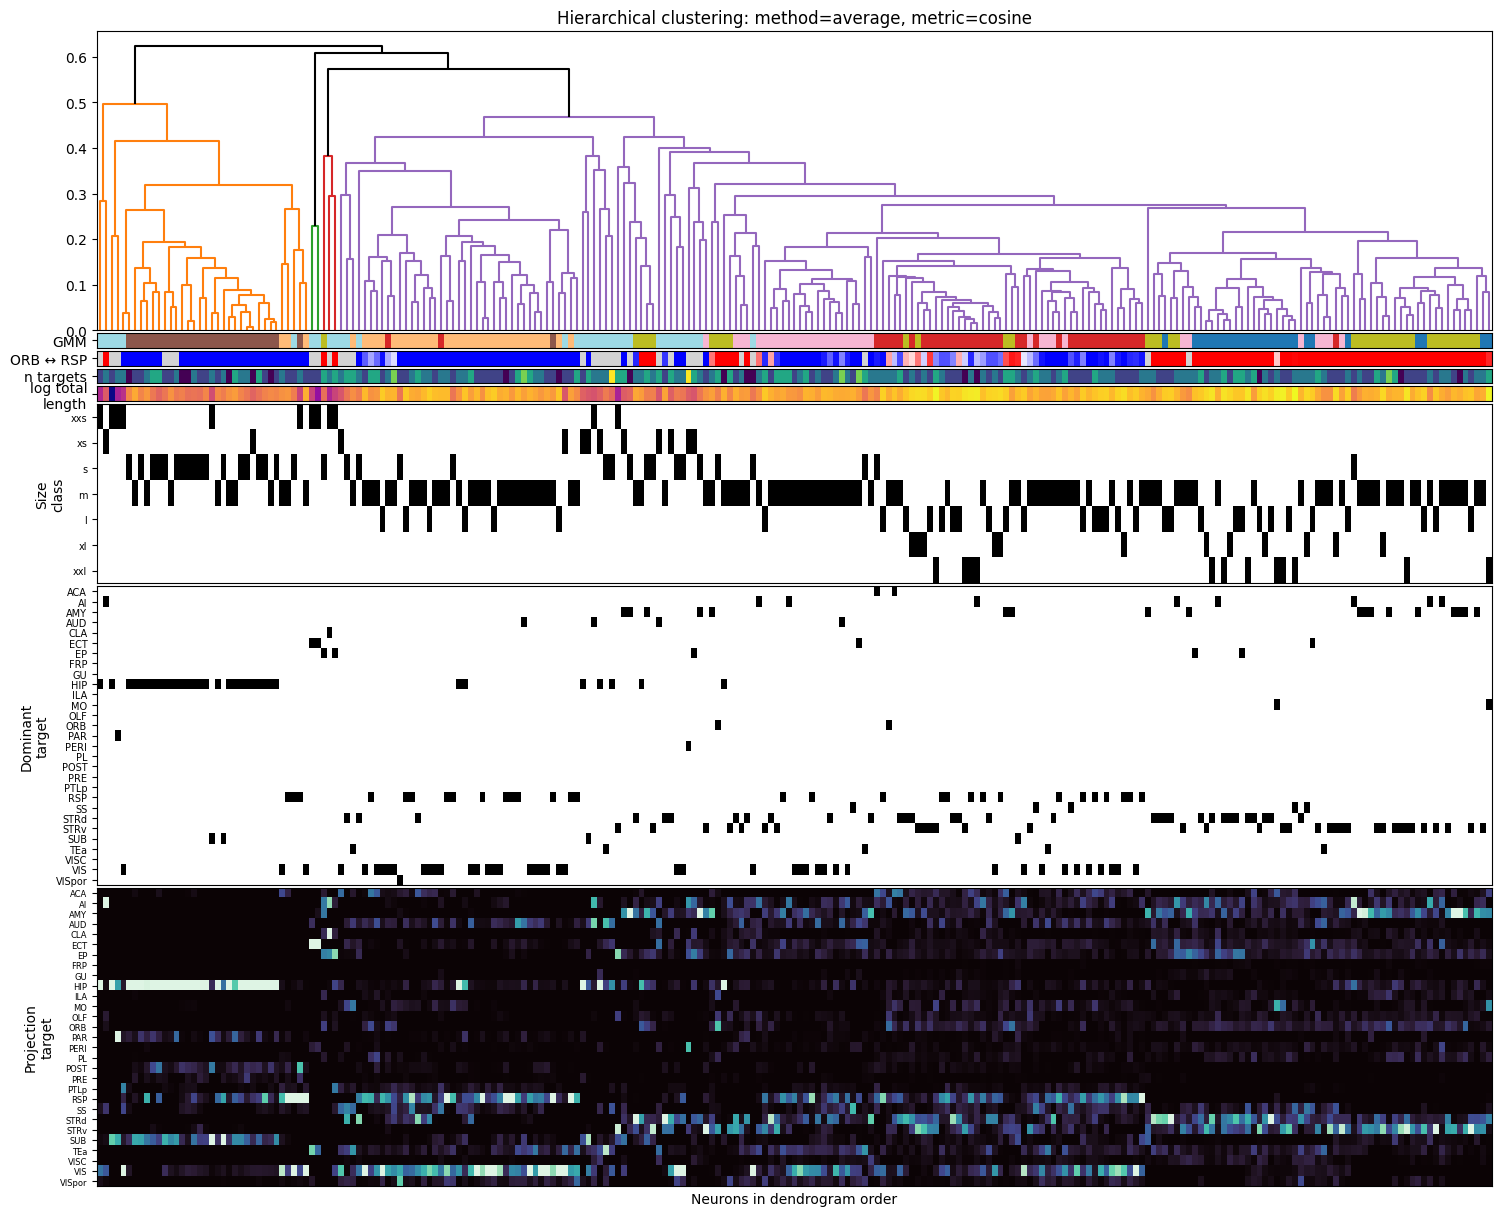

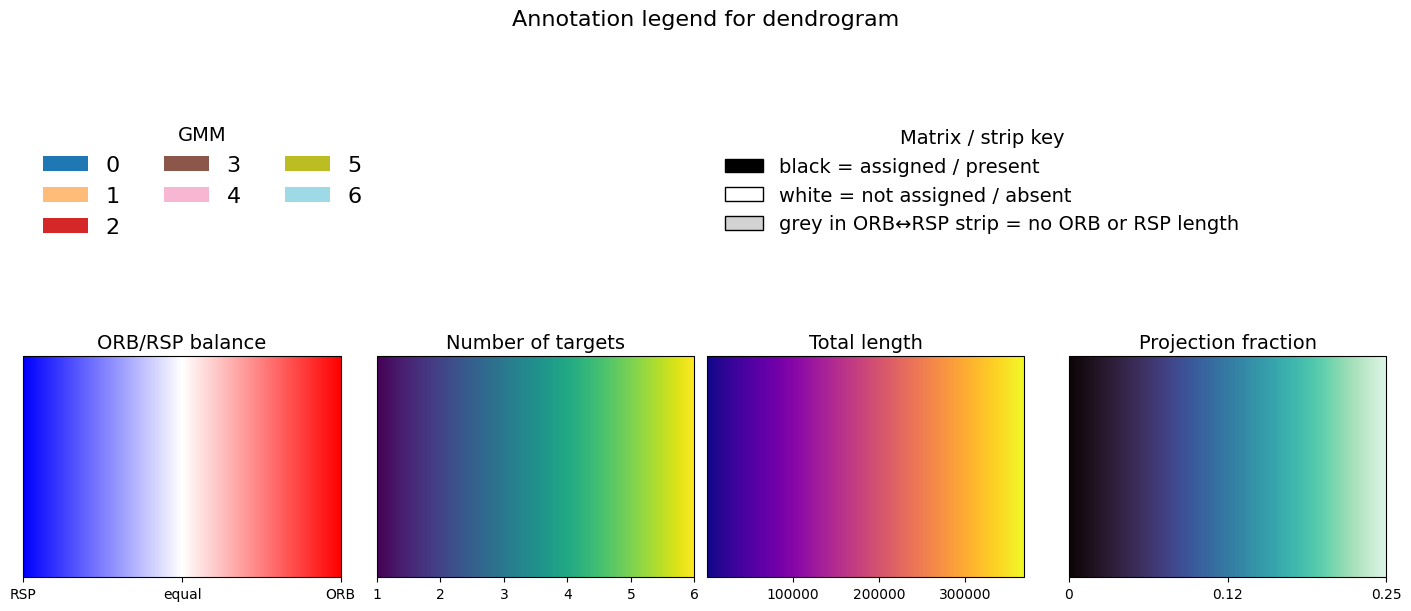

In [18]:
data1, fractions1 = add_projection_features(
    data = ec_snr_data,
    cols = length_cols,
    target_threshold=0.1,
    single_threshold=0.70
)


trans_pipe = ColumnTransformer(
            [('log', 
              make_pipeline(
                          FunctionTransformer(np.log1p)),
              length_cols)])
ec_snr_trans = trans_pipe.fit_transform(ec_snr_data)

fig, axes, hc, leaf_order = plot_projection_dendrogram(
    X = ec_snr_trans,
    data = data1,
    fractions = fractions1,
    target_levels = target_levels,
    method="average",
    metric="cosine",
    color_threshold=0.5,
    figsize=(18, 15),
    frac_vmax=0.4,
    total_length_log=True,
    title=None,
    cluster_labels = gmm_7_labs
)
fig.savefig(
    "Figures/fig_7_dendrogram.pdf",
    bbox_inches="tight",
    facecolor="white"
)


if gmm_7_labs is not None:
    cluster_categories = pd.Categorical(gmm_7_labs).categories
    cmap_cluster = ListedColormap(
        plt.cm.tab20(np.linspace(0, 1, len(cluster_categories)))
    )
    cluster_colors = [cmap_cluster(i) for i in range(len(cluster_categories))]
else:
    cluster_categories = None
    cluster_colors = None

if False:  # change to True if total_length_log=True above
    total_range = (
        np.log1p(data1["total_length"]).min(),
        np.log1p(data1["total_length"]).max()
    )
else:
    total_range = (
        data1["total_length"].min(),
        data1["total_length"].max()
    )

legend_fig = plot_dendrogram_legend_figure(
    cluster_names=cluster_categories,
    cluster_colors=cluster_colors,
    n_targets_range=(
        int(data1["n_targets"].min()),
        int(data1["n_targets"].max())
    ),
    total_length_range=total_range,
    frac_vmax=0.25,
    total_length_log=False,
    cluster_label_name="GMM"
)

legend_fig.savefig(
    "Figures/fig_6_dendrogram_legend.pdf",
    bbox_inches="tight",
    facecolor="white"
)

In [19]:
# Create a dataframe so that a csv file of cluster labels can be accessed by future notebooks.
labels_df = pd.DataFrame({'labels':gmm_7_labs, "neuron_id": ec_snr_data.index})
label_map = ({
    0:'long_xlong_STRd_STRv_AI^ORB~very_lateral',
    1:'med_short_RSP_VIS^RSP~very_medial',
    2:'med_xlong_RSP_VIS_STR^blend~medial',
    3:'short_HIP_SUB^RSP~very_medial',
    4:'med_RSP_VIS_TEa^blend~medial',
    5:'med_AMY_STRv_STRd^ORB~very_lateral',
    6:'xshort_mixed^none~medial'
})

labels_df["names"] = labels_df["labels"].map(label_map)
labels_df.to_csv('Results/labs_l7gmm.csv', index=False)

In [20]:
# The above helps us come up with a sensible ordering for the clusters from medial to lateral, and then placing the two mixed groups with bad tracing at the bottom
# Desired medial to lateral order with the two mixed groups, 4 & 6, at the end
cluster_label_order = [3, 1, 2, 5, 0, 4, 6]
cluster_order = [label_map[i] for i in cluster_label_order]

In [21]:
# Create a cluster name  category column of ec_snr_data so that tables in future can use the same ordering with ease
gmm_7_labs_names = pd.Series(gmm_7_labs).map(label_map)
ec_snr_data["label_names"] = pd.Categorical(
    pd.Series(gmm_7_labs, index=ec_snr_data.index).map(label_map),
    categories=cluster_order,
    ordered=True
)

# Same for numeric labels in case they are also needed
ec_snr_data['labels'] = gmm_7_labs


# Write the dataframe with these two new columns to a new csv file to use in subsequent notebooks.
ec_snr_data.to_csv("Data/ec_snr_data_with_clusters.csv", index=False)

## Table 4

In [22]:
# Check the balance of the classes:
print(ec_snr_data['label_names'].value_counts(sort=False))

label_names
short_HIP_SUB^RSP~very_medial               28
med_short_RSP_VIS^RSP~very_medial           36
med_xlong_RSP_VIS_STR^blend~medial          40
med_AMY_STRv_STRd^ORB~very_lateral          38
long_xlong_STRd_STRv_AI^ORB~very_lateral    26
med_RSP_VIS_TEa^blend~medial                36
xshort_mixed^none~medial                    33
Name: count, dtype: int64


In [23]:
# Explore how the comments are distributed amongst clusters
cluster_comment_table = pd.crosstab(
    ec_snr_data["label_names"],
    ec_snr_data["comment"]
).reindex(cluster_order)

cluster_totals = ec_snr_data.groupby("label_names").size().reindex(cluster_order)
cluster_comment_table["total_neurons"] = cluster_totals
cluster_comment_table

/var/folders/c7/ytg8ypcn5cn63c0pfbjpj5yc0000gp/T/ipykernel_14033/3359150596.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_totals = ec_snr_data.groupby("label_names").size().reindex(cluster_order)


comment,NA injection area has 0 endpoints,NA injection area has 0 endpoints injection area has 0 length,bad tracing,outside of ECL5a,total_neurons
label_names,,,,,
short_HIP_SUB^RSP~very_medial,2,3,2,7,28
med_short_RSP_VIS^RSP~very_medial,0,1,8,0,36
med_xlong_RSP_VIS_STR^blend~medial,0,0,3,1,40
med_AMY_STRv_STRd^ORB~very_lateral,0,2,4,1,38
long_xlong_STRd_STRv_AI^ORB~very_lateral,1,0,2,2,26
med_RSP_VIS_TEa^blend~medial,0,6,6,0,36
xshort_mixed^none~medial,0,7,19,0,33


## Figure 8

In [24]:
# Compute the centroids of the clusters for visualisation purposes.
coord_cols = ["x", "y", "z"]

centroids = (
    ec_snr_data
    .groupby("label_names", observed=True)[coord_cols]
    .mean()
    .reset_index()
)

centroids

,label_names,x,y,z
0,short_HIP_SUB^RSP~very_medial,9989.038086,3130.270141,9038.613225
1,med_short_RSP_VIS^RSP~very_medial,9939.052975,3502.449150,9267.145694
2,med_xlong_RSP_VIS_STR^blend~medial,9840.458607,3692.480016,9464.035730
3,med_AMY_STRv_STRd^ORB~very_lateral,9315.810826,4583.676433,9795.413061
4,long_xlong_STRd_STRv_AI^ORB~very_lateral,8759.960296,4728.437124,9957.911149
5,med_RSP_VIS_TEa^blend~medial,9803.615981,3917.423583,9447.865795
6,xshort_mixed^none~medial,9817.355328,3656.125082,9436.692516


In [25]:
# Sagittal View of Brain Render with the centroids
Path("Figures").mkdir(exist_ok=True)

scene = Scene(title="Cluster centroids in ECL5a")

cluster_colours = {
    'long_xlong_STRd_STRv_AI^ORB~very_lateral': "blue",
    'med_short_RSP_VIS^RSP~very_medial': "orange",
    'med_xlong_RSP_VIS_STR^blend~medial': "red",
    'short_HIP_SUB^RSP~very_medial': "brown",
    'med_RSP_VIS_TEa^blend~medial': "pink",
    'med_AMY_STRv_STRd^ORB~very_lateral': "green",
    'xshort_mixed^none~medial': "cyan",
}

# Plot all neurons faintly
for cluster, df_cluster in ec_snr_data.groupby("label_names", observed=True):
    coords = df_cluster[coord_cols].to_numpy()

    points = Points(
        coords,
        radius=25,
        colors=cluster_colours[cluster],
        alpha=0.15,
    )
    scene.add(points)

# Plot centroids as larger spheres
for _, row in centroids.iterrows():
    cluster = row["label_names"]
    centroid_coord = row[coord_cols].to_numpy().reshape(1, 3)

    centroid_point = Points(
        centroid_coord,
        radius=120,
        colors=cluster_colours[cluster],
        alpha=1,
    )
    scene.add(centroid_point)


scene.add_brain_region("ENTl", alpha=0.1, color="blue")
scene.add_brain_region("ENTm", alpha=0.1, color="blue")


scene.render(camera="sagittal2", zoom=1.5)

scene.plotter.screenshot("Figures/fig_8_saggital2_view.png")

In [26]:
# Top view of brain render with the centroids
Path("Figures").mkdir(exist_ok=True)

scene = Scene(title="Cluster centroids in ECL5a")

cluster_colours = {
    'long_xlong_STRd_STRv_AI^ORB~very_lateral': "blue",
    'med_short_RSP_VIS^RSP~very_medial': "orange",
    'med_xlong_RSP_VIS_STR^blend~medial': "red",
    'short_HIP_SUB^RSP~very_medial': "brown",
    'med_RSP_VIS_TEa^blend~medial': "pink",
    'med_AMY_STRv_STRd^ORB~very_lateral': "green",
    'xshort_mixed^none~medial': "cyan",
}

# Plot all neurons faintly
for cluster, df_cluster in ec_snr_data.groupby("label_names", observed=True):
    coords = df_cluster[coord_cols].to_numpy()

    points = Points(
        coords,
        radius=25,
        colors=cluster_colours[cluster],
        alpha=0.15,
    )
    scene.add(points)

# Plot centroids as larger spheres
for _, row in centroids.iterrows():
    cluster = row["label_names"]
    centroid_coord = row[coord_cols].to_numpy().reshape(1, 3)

    centroid_point = Points(
        centroid_coord,
        radius=120,
        colors=cluster_colours[cluster],
        alpha=1,
    )
    scene.add(centroid_point)


scene.add_brain_region("ENTl", alpha=0.1, color="blue")
scene.add_brain_region("ENTm", alpha=0.1, color="blue")


scene.render(camera="top", zoom=1.5)

scene.plotter.screenshot("Figures/fig_8_top_view.png")